# NF-UQ-NIDS-v2 + Synthetic Augment — XGBoost Multiclass Pipeline

`data/NF-UQ-NIDS-v2.csv` + `data/synthetic_nfv2_augment.csv` birlestirilir ve XGBoost ile
cok-sinifli atak tipi siniflandirmasi yapilir.

**Bu surumdeki degisiklik:** `Generic` sinifi (cok az ornek -> anlamsiz metrik) **tamamen cikariliyor**.
Ayrica config'teki `DROP_CLASSES` listesi ile ileride baska siniflari da tek satirdan eleyebilirsin.


## 1) Config & Importlar

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings, json, time
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib

# ----------------------- CONFIG -----------------------
DATA_DIR      = Path("data")
CSV_FILES     = [DATA_DIR / "NF-UQ-NIDS-v2.csv",
                 DATA_DIR / "synthetic_nfv2_augment.csv"]

OUT_DIR       = Path("artifacts"); OUT_DIR.mkdir(exist_ok=True)

TARGET_PREFS  = ["Attack", "attack", "Label", "label"]   # coklu-sinif icin oncelik: Attack
DROP_COLS     = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "L4_SRC_PORT", "L4_DST_PORT",
                 "Dataset", "dataset", "flow_id", "Flow ID", "Timestamp", "timestamp"]

DROP_CLASSES  = ["Generic"]   # <-- tamamen cikarilacak siniflar (cok az ornek / anlamsiz)
MIN_CLASS     = 50            # bu esigin altindaki nadir siniflar elenir
TEST_SIZE     = 0.20
RANDOM_STATE  = 42
MAX_ROWS      = None          # RAM icin ornekleme (or. 300_000). None = tumu
# ------------------------------------------------------
print("Config hazir. Cikarilan siniflar:", DROP_CLASSES)


Config hazir. Cikarilan siniflar: ['Generic']


## 2) Yukleme + Sema Hizalama (ortak kolon kesisimi)

In [2]:
# ================= HUCRE 2 — bu hucrenin TAMAMINI sil ve bunu yapistir =================
# NF-UQ-NIDS-v2 devasa. read_csv(low_memory=False) => OOM. Cozum: chunk'li + downcast + cap.

PER_FILE_CAP = 150_000     # RAM azsa 80_000'e dusur
CHUNK_SIZE   = 50_000      # kucuk chunk = dusuk pik RAM
READ_KW      = dict(low_memory=True, on_bad_lines="skip", engine="c")

def _downcast(df):
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

def _read_capped(path, cap, chunk_size):
    parts, total = [], 0
    reader = pd.read_csv(path, chunksize=chunk_size, **READ_KW)   # <-- chunksize KEY
    for chunk in reader:
        if cap is not None and total + len(chunk) > cap:
            chunk = chunk.iloc[: cap - total]
        parts.append(_downcast(chunk)); total += len(chunk)
        print(f"   ...{path.name}: {total} satir okundu", end="\r")
        if cap is not None and total >= cap:
            break
    print()
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def load_and_merge(csv_files, per_file_cap=PER_FILE_CAP, chunk_size=CHUNK_SIZE):
    frames, schemas = [], []
    for p in csv_files:
        p = Path(p)
        if not p.exists():
            print(f"[UYARI] Bulunamadi, atlaniyor: {p}"); continue
        df = _read_capped(p, per_file_cap, chunk_size)
        if df.empty:
            print(f"[UYARI] Bos okundu: {p}"); continue
        df["__source__"] = p.name
        print(f"[OK] {p} -> shape={df.shape} (cap={per_file_cap})")
        frames.append(df); schemas.append(set(df.columns))
    if not frames:
        raise FileNotFoundError("Hicbir CSV yuklenemedi.")
    common  = set.intersection(*schemas) | {"__source__"}
    ordered = [c for c in frames[0].columns if c in common]
    frames  = [f[ordered] for f in frames]
    merged  = pd.concat(frames, ignore_index=True)
    print(f"\nOrtak kolon: {len(ordered)} | Birlesik shape: {merged.shape}")
    print(f"Bellek: {merged.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print("Kaynak dagilimi:\n", merged['__source__'].value_counts())
    return merged

df = load_and_merge(CSV_FILES)
df.head(3)

   ...NF-UQ-NIDS-v2.csv: 150000 satir okundu
[OK] data\NF-UQ-NIDS-v2.csv -> shape=(150000, 47) (cap=150000)
   ...synthetic_nfv2_augment.csv: 46084 satir okundu
[OK] data\synthetic_nfv2_augment.csv -> shape=(46084, 42) (cap=150000)

Ortak kolon: 42 | Birlesik shape: (196084, 42)
Bellek: 51.7 MB
Kaynak dagilimi:
 __source__
NF-UQ-NIDS-v2.csv             150000
synthetic_nfv2_augment.csv     46084
Name: count, dtype: int64


,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,__source__
0,6,7.0,420,3,0,0,2,2,0,4293092,...,0,35840,140,0,0,0,0.0,1,DoS,NF-UQ-NIDS-v2.csv
1,6,7.0,280,2,40,1,22,2,20,4294499,...,0,0,0,0,0,0,0.0,1,DoS,NF-UQ-NIDS-v2.csv
2,6,0.0,44,1,40,1,22,2,20,0,...,0,0,0,0,0,0,0.0,0,Benign,NF-UQ-NIDS-v2.csv


## 3) Etiket Kolonu Secimi + Feature/Target Ayrimi

In [3]:
def pick_target(df, prefs):
    for c in prefs:
        if c in df.columns: return c
    raise KeyError(f"Hedef kolon bulunamadi. Aranan: {prefs}")

TARGET = pick_target(df, TARGET_PREFS)
print("Secilen hedef kolon:", TARGET)

leak_cols = set(DROP_COLS) | {"__source__"}
if TARGET != "Label":  leak_cols |= {"Label", "label"}
if TARGET != "Attack": leak_cols |= {"Attack", "attack"}

# --- Feature/target ayrimi ---
feature_cols = [c for c in df.columns if c not in leak_cols and c != TARGET]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
dropped_non_numeric = [c for c in feature_cols if c not in num_cols]
if dropped_non_numeric:
    print("Sayisal olmayan ve atilan feature'lar:", dropped_non_numeric)

X = df[num_cols].copy()

# 1) ONCE y_raw'i olustur
y_raw = df[TARGET].astype(str).str.strip()

# 2) SONRA etiket normalizasyonu (dataset yazim farkliliklarini birlestir)
LABEL_FIX = {
    "Infilteration": "Infiltration",   # CIC-IDS2018 tiposu
    "infilteration": "Infiltration",
    "Web Attack \x96 Brute Force": "Web Attack Brute Force",  # 2017 encoding bozuklugu
    "DoS Hulk": "DoS-Hulk", "DoS GoldenEye": "DoS-GoldenEye",
    "scanning": "Reconnaissance",
    "injection": "Web Attack",
    "Injection": "Web Attack",
    "xss": "Web Attack",
    "Xss": "Web Attack",
    "Exploits": "Exploitation",
    "Shellcode": "Exploitation",
    "mitm": "MITM",
    "ransomware": "Ransomware",
}

y_raw = y_raw.replace(LABEL_FIX)

print(f"\nFeature: {X.shape[1]} | Ornek: {X.shape[0]}")
print("\nSinif dagilimi (normalizasyon sonrasi):\n", y_raw.value_counts())

Secilen hedef kolon: Attack

Feature: 39 | Ornek: 196084

Sinif dagilimi (normalizasyon sonrasi):
 Attack
Benign            49414
DDoS              43053
DoS               35528
Reconnaissance    17491
Web Attack        11597
Exploitation       6045
password           5123
Bot                3248
Brute Force        3240
Infiltration       3209
Backdoor           3042
Fuzzers            3041
MITM               3015
Ransomware         3005
Theft              3002
Worms              3001
Generic              25
Analysis              5
Name: count, dtype: int64


## 4) Sanitizasyon — Inf/NaN + float32 overflow kirpma

In [4]:
def sanitize_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    F32_MAX = np.finfo(np.float32).max
    CLIP    = F32_MAX / 10.0
    over = int((X.abs() > CLIP).sum().sum())
    if over: print(f"[FIX] float32 limitini asan hucre: {over} -> kirpiliyor")
    X = X.clip(lower=-CLIP, upper=CLIP)
    X = X.fillna(X.median(numeric_only=True)).fillna(0.0).astype(np.float32)
    assert np.isfinite(X.values).all(), "Hala finite olmayan deger var!"
    return X

X = sanitize_features(X)
print("Sanitizasyon tamam | min:", float(X.values.min()), "| max:", float(X.values.max()))


[FIX] float32 limitini asan hucre: 3 -> kirpiliyor
Sanitizasyon tamam | min: 0.0 | max: 3.4028234663852886e+37


## 5) Sinif Cikarma (`Generic`) + Nadir Sinif Filtresi + Label Encode

In [5]:
# --- 5a) Config'teki siniflari tamamen cikar (Generic) ---
if DROP_CLASSES:
    drop_mask = y_raw.isin(DROP_CLASSES)
    n_drop = int(drop_mask.sum())
    print(f"DROP_CLASSES {DROP_CLASSES} -> {n_drop} satir cikariliyor")
    X = X.loc[~drop_mask].reset_index(drop=True)
    y_raw = y_raw.loc[~drop_mask].reset_index(drop=True)

# --- 5b) Nadir sinif filtresi ---
vc = y_raw.value_counts()
keep = vc[vc >= MIN_CLASS].index
mask = y_raw.isin(keep)
removed = sorted(set(y_raw) - set(keep))
if removed: print(f"MIN_CLASS={MIN_CLASS} altinda elenen: {removed}")
X = X.loc[mask].reset_index(drop=True)
y_raw = y_raw.loc[mask].reset_index(drop=True)
# ============================================================
# AYNI FEATURE + AYNI LABEL TEKRARLARINI TEMIZLE
# K-Fold içinde duplicate leakage oluşmasını engeller.
# ============================================================

combined = X.copy()
combined["__target__"] = y_raw.to_numpy()

before = len(combined)

combined = combined.drop_duplicates(
    subset=list(X.columns) + ["__target__"],
    keep="first"
).reset_index(drop=True)

removed_duplicates = before - len(combined)

y_raw = combined.pop("__target__").astype(str)
X = combined.reset_index(drop=True)
y_raw = y_raw.reset_index(drop=True)

print(
    f"Ayni feature + ayni label tekrar temizligi: "
    f"{removed_duplicates} satir cikarildi"
)
print(f"Tekrarsiz veri boyutu: {X.shape}")
# ============================================================
# AYNI FEATURE + AYNI LABEL TEKRARLARINI TEMIZLE
# K-Fold içinde duplicate leakage oluşmasını engeller.
# ============================================================

combined = X.copy()
combined["__target__"] = y_raw.to_numpy()

before = len(combined)

combined = combined.drop_duplicates(
    subset=list(X.columns) + ["__target__"],
    keep="first"
).reset_index(drop=True)

removed_duplicates = before - len(combined)

# ============================================================
# CONFLICT TEMIZLIGI
# Ayni feature'lar birden fazla etikette varsa komple sil
# ============================================================

feature_hash = pd.util.hash_pandas_object(
    combined.drop(columns=["__target__"]),
    index=False
)

combined["__feature_hash__"] = feature_hash

conflicting_hashes = (
    combined
    .groupby("__feature_hash__")["__target__"]
    .nunique()
)

conflicting_hashes = conflicting_hashes[
    conflicting_hashes > 1
].index

conflict_count = int(
    combined["__feature_hash__"]
    .isin(conflicting_hashes)
    .sum()
)

if conflict_count > 0:
    print(
        f"Conflict temizligi: {conflict_count} satir siliniyor "
        f"({len(conflicting_hashes)} cakisan feature grubu)"
    )

    combined = combined[
        ~combined["__feature_hash__"]
        .isin(conflicting_hashes)
    ].reset_index(drop=True)

combined = combined.drop(
    columns=["__feature_hash__"]
)

# ============================================================

y_raw = combined.pop("__target__").astype(str)

X = combined.reset_index(drop=True)
y_raw = y_raw.reset_index(drop=True)

print(
    f"Ayni feature + ayni label tekrar temizligi: "
    f"{removed_duplicates} satir cikarildi"
)

print(f"Tekrarsiz veri boyutu: {X.shape}")
# --- 5c) Encode ---
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("\nKalan sinif sayisi:", len(le.classes_))
print("Siniflar:", list(le.classes_))


DROP_CLASSES ['Generic'] -> 25 satir cikariliyor
MIN_CLASS=50 altinda elenen: ['Analysis']
Ayni feature + ayni label tekrar temizligi: 98771 satir cikarildi
Tekrarsiz veri boyutu: (97283, 39)
Conflict temizligi: 66 satir siliniyor (31 cakisan feature grubu)
Ayni feature + ayni label tekrar temizligi: 0 satir cikarildi
Tekrarsiz veri boyutu: (97217, 39)

Kalan sinif sayisi: 16
Siniflar: ['Backdoor', 'Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Exploitation', 'Fuzzers', 'Infiltration', 'MITM', 'Ransomware', 'Reconnaissance', 'Theft', 'Web Attack', 'Worms', 'password']


## 6) Train/Test Split + Overlap Temizligi

In [6]:
# ============================================================
# HOLDOUT SPLIT + TRAIN/TEST OVERLAP TEMIZLIGI
# Final test seti K-Fold sırasında kesinlikle kullanılmayacak.
# ============================================================

if MAX_ROWS is not None and len(X) > MAX_ROWS:
    rng = np.random.RandomState(RANDOM_STATE)

    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        class_target = max(
            1,
            int(round(MAX_ROWS * len(class_indices) / len(X)))
        )

        class_target = min(class_target, len(class_indices))

        selected = rng.choice(
            class_indices,
            size=class_target,
            replace=False
        )

        selected_indices.extend(selected.tolist())

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    X = X.iloc[selected_indices].reset_index(drop=True)
    y = y[selected_indices]

    print(f"RAM ornekleme -> {len(X)} satir")


# Önce final holdout test oluştur
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Train/Test overlap temizliği
# Aynı feature satırı train ve testte varsa testten çıkar.
# ------------------------------------------------------------

before = len(X_te)

train_keys = pd.util.hash_pandas_object(
    X_tr,
    index=False
).to_numpy()

test_keys = pd.util.hash_pandas_object(
    X_te,
    index=False
).to_numpy()

train_key_set = set(train_keys)

keep_test = np.array([
    key not in train_key_set
    for key in test_keys
])

X_te = X_te.iloc[keep_test].reset_index(drop=True)
y_te = y_te[keep_test]

print(
    f"Overlap temizligi: test'ten "
    f"{before - len(X_te)} cakisan satir cikarildi"
)

print(f"Train: {X_tr.shape}")
print(f"Final holdout test: {X_te.shape}")

print("\nTrain sinif dagilimi:")
print(
    pd.Series(
        le.inverse_transform(y_tr)
    ).value_counts()
)

print("\nTest sinif dagilimi:")
print(
    pd.Series(
        le.inverse_transform(y_te)
    ).value_counts()
)

Overlap temizligi: test'ten 0 cakisan satir cikarildi
Train: (77773, 39)
Final holdout test: (19444, 39)

Train sinif dagilimi:
Benign            22766
Web Attack         8672
DDoS               6080
DoS                5413
Reconnaissance     4977
Exploitation       4836
password           3207
Infiltration       2525
Brute Force        2462
Fuzzers            2428
MITM               2412
Backdoor           2404
Ransomware         2404
Theft              2402
Worms              2401
Bot                2384
Name: count, dtype: int64

Test sinif dagilimi:
Benign            5692
Web Attack        2168
DDoS              1520
DoS               1354
Reconnaissance    1245
Exploitation      1209
password           802
Infiltration       631
Brute Force        615
Fuzzers            607
MITM               603
Backdoor           601
Ransomware         601
Theft              600
Worms              600
Bot                596
Name: count, dtype: int64


In [7]:
# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Yalnızca training set üzerinde çalışır.
# Final holdout test setine dokunmaz.
# ============================================================

from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []
cv_oof_pred = np.full(len(y_tr), -1, dtype=np.int32)

for fold, (fold_train_idx, fold_val_idx) in enumerate(
    skf.split(X_tr, y_tr),
    start=1
):
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"{'=' * 60}")

    X_fold_train = X_tr.iloc[fold_train_idx]
    X_fold_val = X_tr.iloc[fold_val_idx]

    y_fold_train = y_tr[fold_train_idx]
    y_fold_val = y_tr[fold_val_idx]

    fold_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=y_fold_train
    )

    fold_model = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.1,

        subsample=0.9,
        colsample_bytree=0.9,

        reg_lambda=1.0,

        objective="multi:softprob",
        num_class=len(le.classes_),

        tree_method="hist",
        eval_metric="mlogloss",

        n_jobs=-1,
        random_state=RANDOM_STATE + fold
    )

    fold_start = time.time()

    fold_model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=fold_sample_weight,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )

    fold_pred = fold_model.predict(X_fold_val).astype(np.int32)

    cv_oof_pred[fold_val_idx] = fold_pred

    fold_acc = accuracy_score(
        y_fold_val,
        fold_pred
    )

    fold_bacc = balanced_accuracy_score(
        y_fold_val,
        fold_pred
    )

    fold_macro_f1 = f1_score(
        y_fold_val,
        fold_pred,
        average="macro",
        zero_division=0
    )

    fold_result = {
        "fold": fold,
        "accuracy": float(fold_acc),
        "balanced_accuracy": float(fold_bacc),
        "macro_f1": float(fold_macro_f1),
        "train_size": int(len(fold_train_idx)),
        "validation_size": int(len(fold_val_idx)),
        "training_seconds": float(time.time() - fold_start)
    }

    cv_results.append(fold_result)

    print(f"Accuracy          : {fold_acc:.4f}")
    print(f"Balanced Accuracy : {fold_bacc:.4f}")
    print(f"Macro-F1          : {fold_macro_f1:.4f}")
    print(
        f"Egitim suresi     : "
        f"{fold_result['training_seconds']:.1f} sn"
    )


cv_df = pd.DataFrame(cv_results)

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION OZETI")
print("=" * 60)

print(
    cv_df[
        [
            "fold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "training_seconds"
        ]
    ].round(4)
)

print("\nCV Ortalama ± Standart Sapma")

print(
    f"Accuracy          : "
    f"{cv_df['accuracy'].mean():.4f} "
    f"± {cv_df['accuracy'].std(ddof=1):.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{cv_df['balanced_accuracy'].mean():.4f} "
    f"± {cv_df['balanced_accuracy'].std(ddof=1):.4f}"
)

print(
    f"Macro-F1          : "
    f"{cv_df['macro_f1'].mean():.4f} "
    f"± {cv_df['macro_f1'].std(ddof=1):.4f}"
)


# Out-of-fold genel sonuç
assert (cv_oof_pred >= 0).all(), (
    "Bazı training satırları OOF tahmini alamadı."
)

oof_acc = accuracy_score(
    y_tr,
    cv_oof_pred
)

oof_bacc = balanced_accuracy_score(
    y_tr,
    cv_oof_pred
)

oof_macro_f1 = f1_score(
    y_tr,
    cv_oof_pred,
    average="macro",
    zero_division=0
)

print("\nOut-of-Fold Genel Sonuc")

print(f"OOF Accuracy          : {oof_acc:.4f}")
print(f"OOF Balanced Accuracy : {oof_bacc:.4f}")
print(f"OOF Macro-F1          : {oof_macro_f1:.4f}")


FOLD 1/5
Accuracy          : 0.9356
Balanced Accuracy : 0.9174
Macro-F1          : 0.9211
Egitim suresi     : 16.5 sn

FOLD 2/5
Accuracy          : 0.9449
Balanced Accuracy : 0.9320
Macro-F1          : 0.9330
Egitim suresi     : 17.1 sn

FOLD 3/5
Accuracy          : 0.9410
Balanced Accuracy : 0.9247
Macro-F1          : 0.9276
Egitim suresi     : 17.6 sn

FOLD 4/5
Accuracy          : 0.9373
Balanced Accuracy : 0.9204
Macro-F1          : 0.9221
Egitim suresi     : 18.1 sn

FOLD 5/5
Accuracy          : 0.9396
Balanced Accuracy : 0.9236
Macro-F1          : 0.9256
Egitim suresi     : 18.2 sn

5-FOLD CROSS-VALIDATION OZETI
   fold  accuracy  balanced_accuracy  macro_f1  training_seconds
0     1    0.9356             0.9174    0.9211           16.4549
1     2    0.9449             0.9320    0.9330           17.1298
2     3    0.9410             0.9247    0.9276           17.6214
3     4    0.9373             0.9204    0.9221           18.0552
4     5    0.9396             0.9236    0.9256   

## 7) XGBoost Egitimi (class imbalance -> sample_weight)

In [8]:
# ============================================================
# FINAL XGBOOST MODEL
# K-Fold yalnızca değerlendirme içindi.
# Final model, tüm X_tr üzerinde yeniden eğitilir.
# X_te yalnızca son değerlendirme için kullanılır.
# ============================================================

sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_tr
)

model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,

    subsample=0.9,
    colsample_bytree=0.9,

    reg_lambda=1.0,

    objective="multi:softprob",
    num_class=len(le.classes_),

    tree_method="hist",
    eval_metric="mlogloss",

    n_jobs=-1,
    random_state=RANDOM_STATE
)

t0 = time.time()

model.fit(
    X_tr,
    y_tr,
    sample_weight=sample_weight,
    eval_set=[(X_te, y_te)],
    verbose=False
)

print(
    f"Final model egitim suresi: "
    f"{time.time() - t0:.1f} sn"
)

Final model egitim suresi: 18.9 sn


## 8) Degerlendirme

In [9]:
y_pred = model.predict(X_te)
acc  = accuracy_score(y_te, y_pred)
bacc = balanced_accuracy_score(y_te, y_pred)
mf1  = f1_score(y_te, y_pred, average="macro")
print(f"Accuracy          : {acc:.4f}")
print(f"Balanced Accuracy : {bacc:.4f}")
print(f"Macro-F1          : {mf1:.4f}\n")
print(classification_report(y_te, y_pred, target_names=le.classes_, digits=3, zero_division=0))


Accuracy          : 0.9408
Balanced Accuracy : 0.9237
Macro-F1          : 0.9270

                precision    recall  f1-score   support

      Backdoor      0.961     0.913     0.937       601
        Benign      0.987     0.985     0.986      5692
           Bot      0.910     0.928     0.919       596
   Brute Force      0.800     0.893     0.844       615
          DDoS      0.962     0.961     0.961      1520
           DoS      0.900     0.932     0.916      1354
  Exploitation      0.894     0.902     0.898      1209
       Fuzzers      0.988     0.937     0.962       607
  Infiltration      0.926     0.894     0.910       631
          MITM      0.984     0.927     0.955       603
    Ransomware      0.981     0.965     0.973       601
Reconnaissance      0.943     0.924     0.933      1245
         Theft      0.983     0.980     0.982       600
    Web Attack      0.905     0.940     0.922      2168
         Worms      0.967     0.928     0.947       600
      password      0

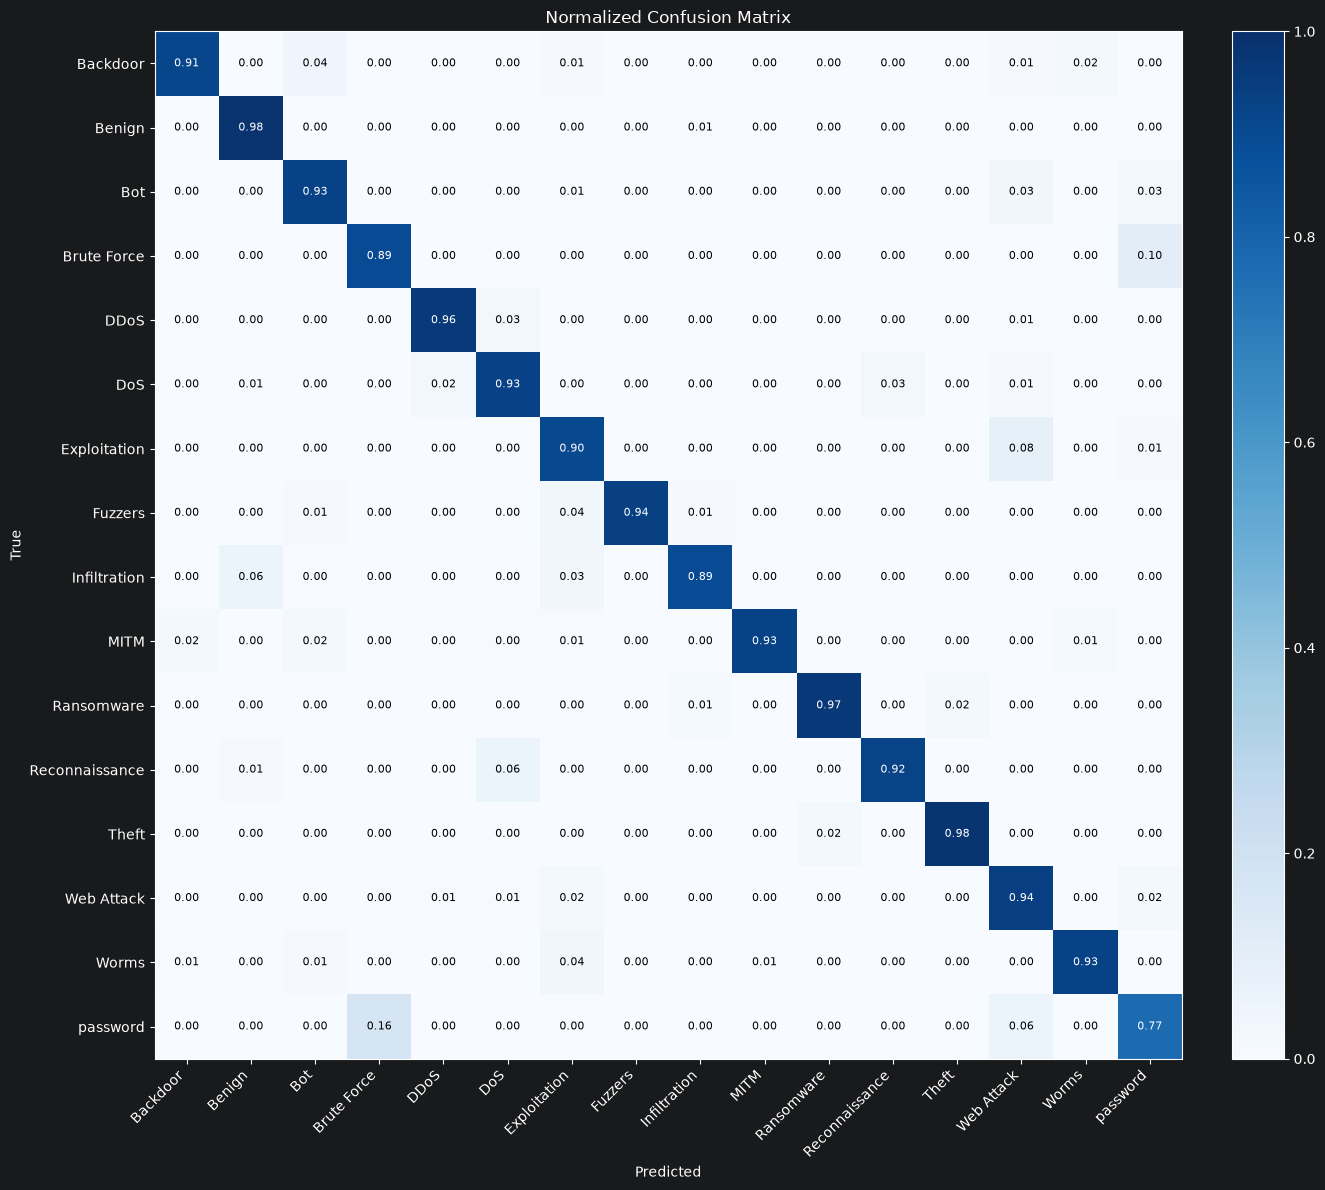

In [10]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(min(2+len(le.classes_),14), min(2+len(le.classes_),12)))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(le.classes_))); ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha="right"); ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Normalized Confusion Matrix")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j]>0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(OUT_DIR/"confusion_matrix.png", dpi=120); plt.show()


## 9) Artifact Kaydi

In [11]:
joblib.dump(model, OUT_DIR/"xgb_nfv2_model.joblib")
joblib.dump(le,    OUT_DIR/"label_encoder.joblib")
joblib.dump(list(X.columns), OUT_DIR/"feature_names.joblib")
metrics = {"accuracy": float(acc), "balanced_accuracy": float(bacc), "macro_f1": float(mf1),
           "n_classes": int(len(le.classes_)), "classes": list(map(str, le.classes_)),
           "dropped_classes": DROP_CLASSES,
           "n_train": int(len(X_tr)), "n_test": int(len(X_te)), "n_features": int(X.shape[1])}
with open(OUT_DIR/"metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("Kaydedildi ->", OUT_DIR.resolve())
print(json.dumps(metrics, indent=2, ensure_ascii=False))


Kaydedildi -> C:\Users\egemen.keles\PycharmProjects\mitre_mapper\artifacts
{
  "accuracy": 0.9408043612425427,
  "balanced_accuracy": 0.9237391718683974,
  "macro_f1": 0.9269501347924499,
  "n_classes": 16,
  "classes": [
    "Backdoor",
    "Benign",
    "Bot",
    "Brute Force",
    "DDoS",
    "DoS",
    "Exploitation",
    "Fuzzers",
    "Infiltration",
    "MITM",
    "Ransomware",
    "Reconnaissance",
    "Theft",
    "Web Attack",
    "Worms",
    "password"
  ],
  "dropped_classes": [
    "Generic"
  ],
  "n_train": 77773,
  "n_test": 19444,
  "n_features": 39
}


SyntaxError: invalid syntax (2488968637.py, line 50)